In [7]:
!python --version
!nvidia-smi

Python 3.13.15
Wed Sep 30 14:45:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------------------

In [8]:
!pip install monai nibabel SimpleITK -q

In [9]:
import monai
import nibabel as nib
import SimpleITK as sitk
print("MONAI version:", monai.__version__)
print("All imports successful")

MONAI version: 1.6.1
All imports successful


In [10]:
import os
from monai.apps import DecathlonDataset

# Ensure the data directory exists
os.makedirs('./data', exist_ok=True)

dataset = DecathlonDataset(
    root_dir="./data",
    task="Task01_BrainTumour",
    section="validation",
    download=True,
    cache_num=0,
)

print("Number of cases downloaded:", len(dataset))

Task01_BrainTumour.tar: 7.09GB [09:10, 13.8MB/s]                            


2026-09-30 14:56:08,636 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2026-09-30 14:56:08,639 - INFO - Downloaded: data/Task01_BrainTumour.tar
2026-09-30 14:56:08,640 - INFO - Writing into directory: data.
Number of cases downloaded: 96


In [11]:
case = dataset[0]
print(type(case))
print(case.keys() if hasattr(case, 'keys') else "no keys")

<class 'dict'>
dict_keys(['image', 'label'])


In [12]:
image = case["image"]
label = case["label"]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label type:", type(label))
print("Label shape:", label.shape)

Image type: <class 'monai.data.meta_tensor.MetaTensor'>
Image shape: torch.Size([240, 240, 155, 4])
Label type: <class 'monai.data.meta_tensor.MetaTensor'>
Label shape: torch.Size([240, 240, 155])


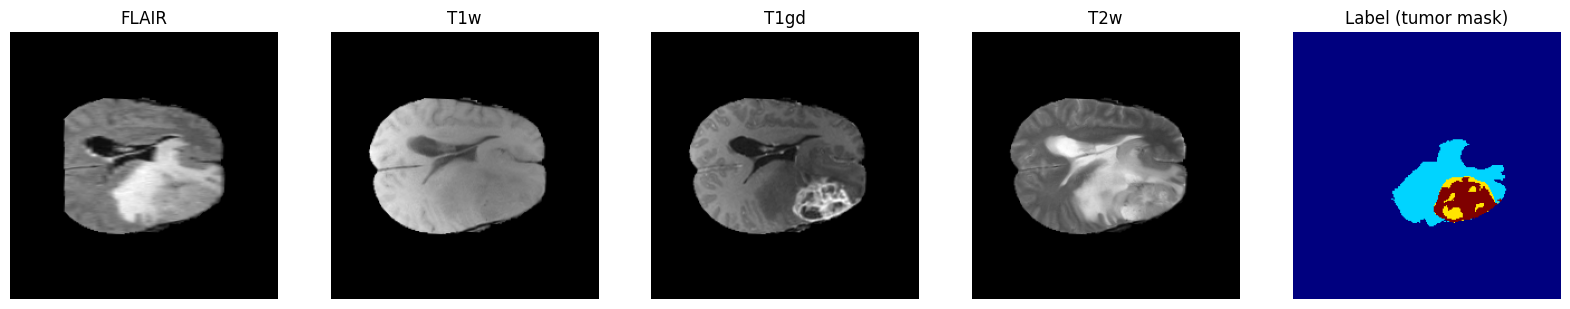

In [13]:
import matplotlib.pyplot as plt

# pick a middle slice along the 3rd axis (depth)
slice_idx = 86

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

modality_names = ["FLAIR", "T1w", "T1gd", "T2w"]
for i in range(4):
    axes[i].imshow(image[:, :, slice_idx, i], cmap="gray")
    axes[i].set_title(modality_names[i])
    axes[i].axis("off")

axes[4].imshow(label[:, :, slice_idx], cmap="jet")
axes[4].set_title("Label (tumor mask)")
axes[4].axis("off")

plt.show()

In [14]:
import numpy as np

label_np = label.numpy() if hasattr(label, 'numpy') else np.array(label)

# Count voxels for each label value
unique_vals, counts = np.unique(label_np, return_counts=True)
for val, count in zip(unique_vals, counts):
    print(f"Label {val}: {count} voxels")

Label 0.0: 8717673 voxels
Label 1.0: 133618 voxels
Label 2.0: 34343 voxels
Label 3.0: 42366 voxels


In [15]:
# Get voxel spacing from the image metadata
affine = image.affine if hasattr(image, 'affine') else image.meta['affine']
print("Affine matrix:\n", affine)

# Voxel dimensions are the diagonal scale of the affine matrix
voxel_dims = np.abs(np.diag(np.array(affine))[:3])
print("Voxel dimensions (mm):", voxel_dims)

voxel_volume_mm3 = voxel_dims[0] * voxel_dims[1] * voxel_dims[2]
print("Volume per voxel (mm³):", voxel_volume_mm3)

Affine matrix:
 tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]], dtype=torch.float64)
Voxel dimensions (mm): [1. 1. 1.]
Volume per voxel (mm³): 1.0


/tmp/ipykernel_975/2807942059.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  voxel_dims = np.abs(np.diag(np.array(affine))[:3])


In [20]:
import json

with open("./data/Task01_BrainTumour/dataset.json", "r") as f:
    meta = json.load(f)

print(json.dumps(meta.get("labels", {}), indent=2))

{
  "0": "background",
  "1": "edema",
  "2": "non-enhancing tumor",
  "3": "enhancing tumour"
}


In [21]:
labels_of_interest = {1: "Edema", 2: "Non-enhancing tumor core", 3: "Enhancing tumor"}

print("--- Tumor Volumes ---")
total_tumor_voxels = 0
for val, name in labels_of_interest.items():
    voxel_count = counts[unique_vals == val][0]
    volume_cm3 = voxel_count * voxel_volume_mm3 / 1000
    print(f"{name}: {volume_cm3:.2f} cm³")
    total_tumor_voxels += voxel_count

total_volume_cm3 = (total_tumor_voxels * voxel_volume_mm3) / 1000
print(f"\nTotal tumor volume (all sub-regions combined): {total_volume_cm3:.2f} cm³")

--- Tumor Volumes ---
Edema: 133.62 cm³
Non-enhancing tumor core: 34.34 cm³
Enhancing tumor: 42.37 cm³

Total tumor volume (all sub-regions combined): 210.33 cm³


In [19]:
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, squareform

# RANO measures the enhancing tumour (label 3) on post-contrast T1
et_mask = (label_np == 3).astype(np.uint8)
best_slice_idx = int(np.argmax(et_mask.sum(axis=(0, 1))))
best_slice_mask = et_mask[:, :, best_slice_idx]
print(f"Slice with largest enhancing area: {best_slice_idx} ({best_slice_mask.sum()} voxels)")

pts = np.argwhere(best_slice_mask) * voxel_dims[:2]     # pixel coordinates in mm
hull = pts[ConvexHull(pts).vertices]
D = squareform(pdist(hull))
i, j = np.unravel_index(np.argmax(D), D.shape)
diameter_1 = round(float(D[i, j]), 1)                   # longest diameter

u = (hull[j] - hull[i]) / D[i, j]                       # direction of longest diameter
v = np.array([-u[1], u[0]])                             # perpendicular direction
pu, pv = pts @ u, pts @ v
bins = np.floor(pu).astype(int)
diameter_2 = round(float(max(pv[bins == b].max() - pv[bins == b].min() for b in np.unique(bins))), 1)

print(f"Longest diameter: {diameter_1} mm")
print(f"Longest perpendicular diameter: {diameter_2} mm")
print(f"Bidimensional product (RANO-style): {diameter_1 * diameter_2:.1f} mm²")

Slice with largest enhancing area: 80 (1477 voxels)
Longest diameter: 57.3 mm
Longest perpendicular diameter: 41.2 mm
Bidimensional product (RANO-style): 2360.8 mm²


In [22]:
et_volume_cm3 = (counts[unique_vals == 3][0] * voxel_volume_mm3) / 1000
print("=== Summary for this patient ===")
print(f"Total lesion volume (incl. oedema): {total_volume_cm3:.2f} cm³")
print(f"Enhancing tumour volume: {et_volume_cm3:.2f} cm³")
print(f"RANO-style bidimensional product (enhancing tumour, slice {best_slice_idx}): {diameter_1 * diameter_2:.1f} mm²")

=== Summary for this patient ===
Total lesion volume (incl. oedema): 210.33 cm³
Enhancing tumour volume: 42.37 cm³
RANO-style bidimensional product (enhancing tumour, slice 80): 2360.8 mm²
